In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go


plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
birds_df = pd.read_csv(
    "../cleaned_data/birds_cleaned.csv"
)

birds_df["Date"] = pd.to_datetime(
    birds_df["Date"]
)

birds_df.head()

,AOU_Code,AcceptedTSN,Admin_Sheet,Admin_Unit_Code,Common_Name,Date,Distance,Disturbance,End_Time,Flyover_Observed,Habitat,Humidity,ID_Method,Initial_Three_Min_Cnt,Interval_Length,Location_Type,NPSTaxonCode,Observer,PIF_Watchlist_Status,Plot_Name,Regional_Stewardship_Status,Scientific_Name,Sex,Site_Name,Sky,Start_Time,Temperature,Visit,Wind,Year,Month,Month_Name,Quarter,Season
0,EATO,179276.0,ANTI,ANTI,Eastern Towhee,2018-05-22,<= 50 Meters,No effect on count,06:29:00,False,Forest,79.400002,Singing,True,0-2.5 min,Forest,83803.0,Elizabeth Oswald,False,ANTI-0036,True,Pipilo erythrophthalmus,Undetermined,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
1,WBNU,178775.0,ANTI,ANTI,White-breasted Nuthatch,2018-05-22,<= 50 Meters,No effect on count,06:29:00,False,Forest,79.400002,Calling,True,0-2.5 min,Forest,90935.0,Elizabeth Oswald,False,ANTI-0036,False,Sitta carolinensis,Unknown,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
2,RBWO,178195.0,ANTI,ANTI,Red-bellied Woodpecker,2018-05-22,50 - 100 Meters,No effect on count,06:29:00,False,Forest,79.400002,Calling,False,2.5 - 5 min,Forest,84865.0,Elizabeth Oswald,False,ANTI-0036,False,Melanerpes carolinus,Unknown,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
3,OROR,179064.0,ANTI,ANTI,Orchard Oriole,2018-05-22,<= 50 Meters,No effect on count,06:29:00,False,Forest,79.400002,Singing,False,2.5 - 5 min,Forest,93634.0,Elizabeth Oswald,False,ANTI-0036,False,Icterus spurius,Unknown,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring
4,NOMO,178620.0,ANTI,ANTI,Northern Mockingbird,2018-05-22,<= 50 Meters,No effect on count,06:29:00,False,Forest,79.400002,Visualization,False,2.5 - 5 min,Forest,88394.0,Elizabeth Oswald,False,ANTI-0036,False,Mimus polyglottos,Unknown,ANTI 1,Cloudy/Overcast,06:19:00,19.9,1,Calm (< 1 mph) smoke rises vertically,2018,5,May,2,Spring


In [3]:
print("Shape :", birds_df.shape)

birds_df.info()

Shape : (15372, 34)
<class 'pandas.DataFrame'>
RangeIndex: 15372 entries, 0 to 15371
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   AOU_Code                     15372 non-null  str           
 1   AcceptedTSN                  15372 non-null  float64       
 2   Admin_Sheet                  15372 non-null  str           
 3   Admin_Unit_Code              15372 non-null  str           
 4   Common_Name                  15372 non-null  str           
 5   Date                         15372 non-null  datetime64[us]
 6   Distance                     15372 non-null  str           
 7   Disturbance                  15372 non-null  str           
 8   End_Time                     15372 non-null  str           
 9   Flyover_Observed             15372 non-null  bool          
 10  Habitat                      15372 non-null  str           
 11  Humidity                     153

In [4]:
monthly_obs = (
    birds_df.groupby("Month_Name")
    .size()
    .reset_index(name="Observation_Count")
)

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

monthly_obs["Month_Name"] = pd.Categorical(
    monthly_obs["Month_Name"],
    categories=month_order,
    ordered=True
)

monthly_obs = monthly_obs.sort_values(
    "Month_Name"
)

monthly_obs

,Month_Name,Observation_Count
2,May,4864
1,June,6211
0,July,4297


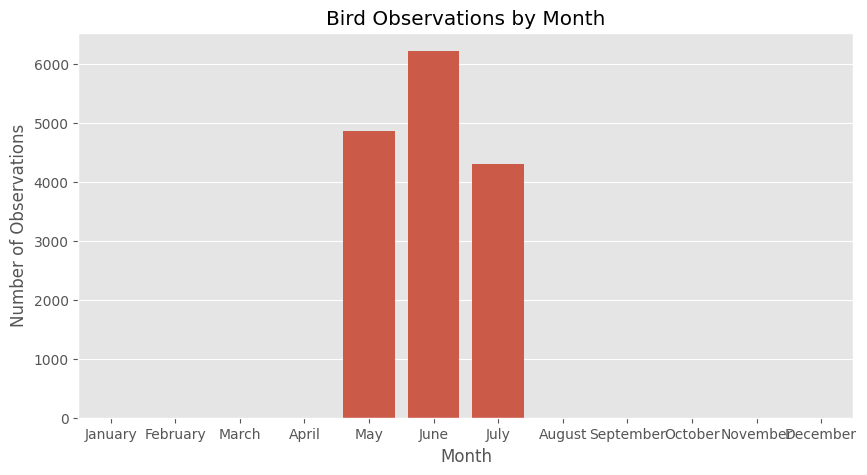

<Figure size 640x480 with 0 Axes>

In [19]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=monthly_obs,
    x="Month_Name",
    y="Observation_Count"
)

plt.title("Bird Observations by Month")
plt.xlabel("Month")
plt.ylabel("Number of Observations")

plt.show()

plt.savefig(
    "../images/temporal/monthly_observations.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [6]:
fig = px.bar(
    monthly_obs,
    x="Month_Name",
    y="Observation_Count",
    title="Bird Observations by Month"
)

fig.show()

In [7]:
season_counts = (
    birds_df["Season"]
    .value_counts()
    .reset_index()
)

season_counts.columns = [
    "Season",
    "Observation_Count"
]

season_counts

,Season,Observation_Count
0,Summer,10508
1,Spring,4864


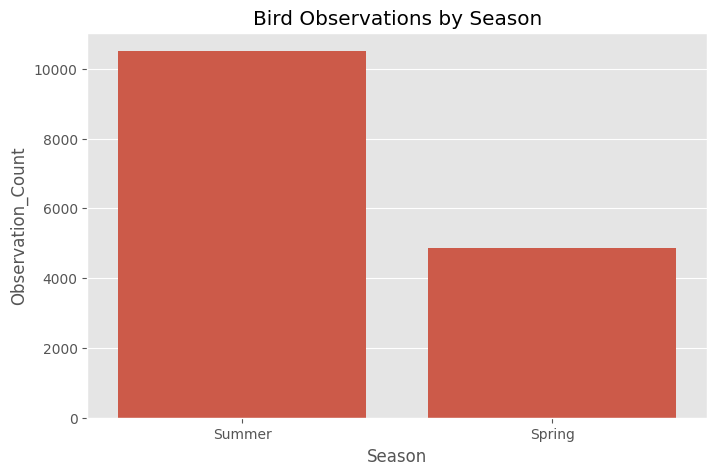

In [8]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=season_counts,
    x="Season",
    y="Observation_Count"
)

plt.title("Bird Observations by Season")

plt.show()

In [20]:
fig = px.pie(
    season_counts,
    names="Season",
    values="Observation_Count",
    title="Seasonal Observation Distribution"
)

fig.show()

plt.savefig(
    "../images/temporal/season_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [17]:
habitat_month = pd.crosstab(
    birds_df["Month_Name"],
    birds_df["Habitat"]
)

month_order = ["May", "June", "July"]

habitat_month = habitat_month.reindex(month_order)

habitat_month

Habitat,Forest,Grassland
Month_Name,,
May,2390,2474
June,4013,2198
July,2143,2154


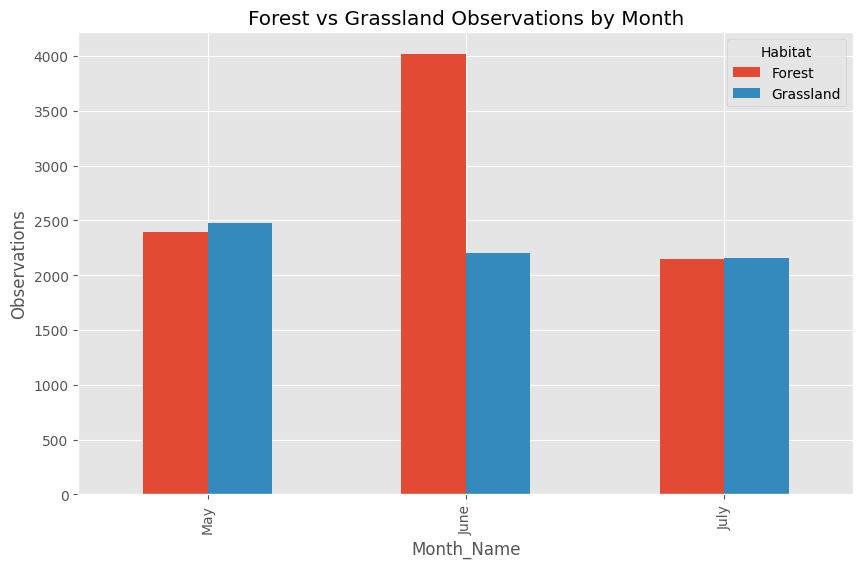

<Figure size 640x480 with 0 Axes>

In [21]:
habitat_month.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Forest vs Grassland Observations by Month"
)

plt.ylabel("Observations")

plt.show()

plt.savefig(
    "../images/temporal/habitat_month_comparisons.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [12]:
daily_trend = (
    birds_df.groupby("Date")
    .size()
    .reset_index(name="Observations")
)

daily_trend.head()

,Date,Observations
0,2018-05-07,358
1,2018-05-08,192
2,2018-05-10,465
3,2018-05-11,189
4,2018-05-12,201


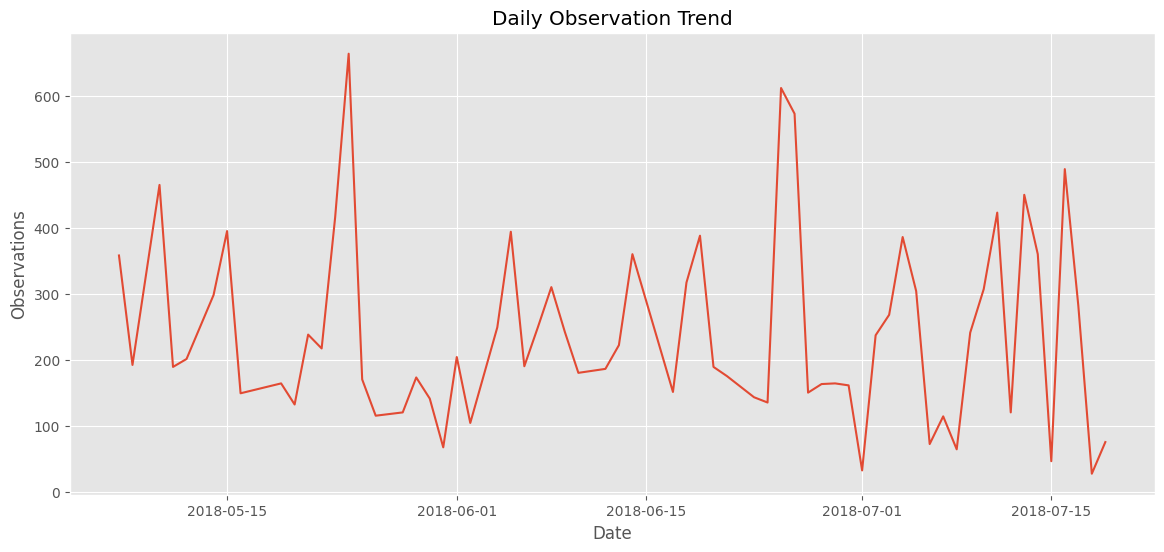

<Figure size 640x480 with 0 Axes>

In [22]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_trend["Date"],
    daily_trend["Observations"]
)

plt.title(
    "Daily Observation Trend"
)

plt.xlabel("Date")

plt.ylabel("Observations")

plt.show()

plt.savefig(
    "../images/temporal/daily_observation_trend.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [14]:
fig = px.line(
    daily_trend,
    x="Date",
    y="Observations",
    title="Daily Observation Trend"
)

fig.show()

In [15]:
visit_counts = (
    birds_df["Visit"]
    .value_counts()
    .sort_index()
)

visit_counts

Visit
1    6856
2    6410
3    2106
Name: count, dtype: int64

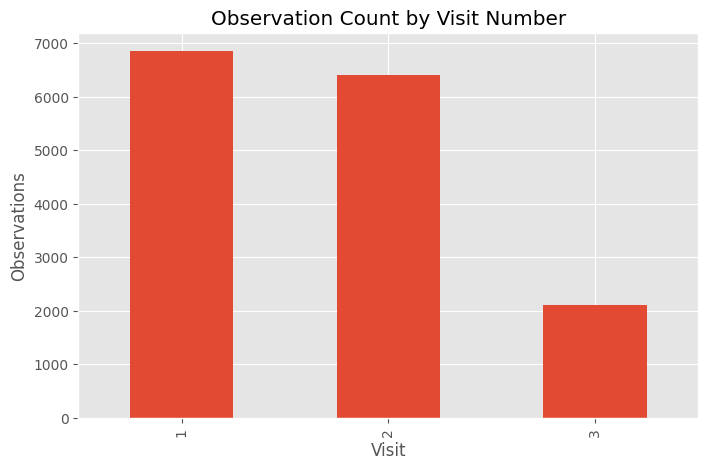

In [16]:
plt.figure(figsize=(8,5))

visit_counts.plot(
    kind="bar"
)

plt.title(
    "Observation Count by Visit Number"
)

plt.xlabel("Visit")

plt.ylabel("Observations")

plt.show()

## Key Findings

1. Most bird observations occurred during ______

2. Summer accounted for ______ observations.

3. Forest habitat showed ______ observations than Grassland.

4. Observation activity peaked during ______.

5. Visit number ______ recorded maximum observations.

1. June had the highest observations
   → 6,211 observations

2. May had
   → 4,864 observations

3. July had
   → 4,297 observations

4. Summer contributed
   → 10,508 observations (68.4%)

5. Spring contributed
   → 4,864 observations (31.6%)

6. Forest observations peaked strongly in June
   → 4,013 observations

7. Grassland observations were relatively balanced
   across May, June and July

8. Visit 1 and Visit 2 account for most observations
   Visit 1 → 6,856
   Visit 2 → 6,410
   Visit 3 → 2,106